# Step 6 — Test a momentum-only model on later dates

We train on the earliest 75% of observations and test on the latest 25%. A five-trading-day gap separates the periods so no training target reaches into the test period. Dates are never shuffled.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "aapl_momentum_target.csv"
data = pd.read_csv(DATA_PATH, parse_dates=["date"], index_col="date").sort_index()
data.head()

,aapl_adjusted_close,spy_adjusted_close,aapl_momentum_5d,aapl_future_return_5d,spy_future_return_5d,outperformed
date,,,,,,
2023-01-10,128.548233,373.466339,0.045254,0.034269,0.002330,1
2023-01-11,131.262222,378.189850,0.056426,0.013334,-0.017395,1
2023-01-12,131.183533,379.566772,0.067109,0.033431,-0.002721,1
2023-01-13,132.510986,381.039276,0.039654,0.047121,0.005345,1
2023-01-17,133.671341,380.341309,0.044487,0.048477,0.006109,1


## Chronological split

The model learns from the training period only. We remove five observations immediately before the test period because each answer looks five trading days ahead.

In [2]:
test_size = int(len(data) * 0.25)
gap = 5
test_start = len(data) - test_size

train = data.iloc[: test_start - gap].copy()
gap_data = data.iloc[test_start - gap : test_start].copy()
test = data.iloc[test_start:].copy()

split_summary = pd.DataFrame({
    "Rows": [len(train), len(gap_data), len(test)],
    "Start": [train.index.min(), gap_data.index.min(), test.index.min()],
    "End": [train.index.max(), gap_data.index.max(), test.index.max()],
}, index=["Training", "Safety gap", "Testing"])
split_summary

,Rows,Start,End
Training,364,2023-01-10,2024-06-21
Safety gap,5,2024-06-24,2024-06-28
Testing,123,2024-07-01,2024-12-23


## Majority-class baseline

The baseline always predicts whichever answer occurred most often in the training data. Any useful model should be compared with this deliberately simple rule.

In [3]:
feature = ["aapl_momentum_5d"]
target = "outperformed"

X_train = train[feature]
y_train = train[target].astype(int)
X_test = test[feature]
y_test = test[target].astype(int)

majority_class = int(y_train.mode().iloc[0])
baseline_predictions = pd.Series(majority_class, index=y_test.index)
print("Training majority class:", majority_class)
print("Meaning:", "Outperform" if majority_class == 1 else "Do not outperform")

Training majority class: 1
Meaning: Outperform


## Momentum-only logistic regression

Logistic regression estimates a probability between 0 and 1 from five-day momentum. A probability of at least 0.5 becomes a prediction of outperformance. Standardization is learned from the training period only.

In [4]:
model = make_pipeline(StandardScaler(), LogisticRegression(random_state=42))
model.fit(X_train, y_train)

model_probabilities = model.predict_proba(X_test)[:, 1]
model_predictions = model.predict(X_test)

print("First five predicted probabilities:")
pd.Series(model_probabilities, index=X_test.index, name="outperformance_probability").head()

First five predicted probabilities:


date
2024-07-01    0.494989
2024-07-02    0.482175
2024-07-03    0.497557
2024-07-05    0.478400
2024-07-08    0.452794
Name: outperformance_probability, dtype: float64

## Compare performance

- **Accuracy:** percentage of all answers predicted correctly.
- **Precision:** when the model predicted outperformance, how often it was right.
- **Recall:** percentage of actual outperformance cases the model identified.
- **ROC AUC:** how well probabilities rank outperforming dates above non-outperforming dates; 0.5 is similar to random ranking.

ROC AUC is not meaningful for the baseline because it assigns the same score to every date.

In [5]:
def classification_metrics(actual, predicted, probabilities=None):
    return {
        "Accuracy": accuracy_score(actual, predicted),
        "Precision": precision_score(actual, predicted, zero_division=0),
        "Recall": recall_score(actual, predicted, zero_division=0),
        "ROC AUC": roc_auc_score(actual, probabilities) if probabilities is not None else float("nan"),
    }

results = pd.DataFrame({
    "Majority baseline": classification_metrics(y_test, baseline_predictions),
    "Momentum model": classification_metrics(y_test, model_predictions, model_probabilities),
}).T
results.round(3)

,Accuracy,Precision,Recall,ROC AUC
Majority baseline,0.545,0.545,1.000,NaN
Momentum model,0.504,0.529,0.821,0.4


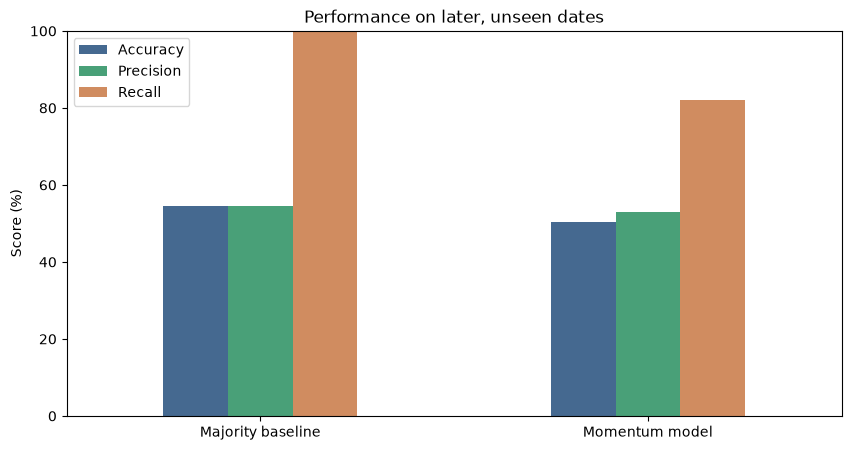

In [6]:
ax = (results[["Accuracy", "Precision", "Recall"]] * 100).plot.bar(
    figsize=(10, 5), rot=0, color=["#456990", "#49a078", "#d08c60"]
)
ax.set_ylim(0, 100)
ax.set_title("Performance on later, unseen dates")
ax.set_ylabel("Score (%)")
ax.set_xlabel("")
plt.show()

## Interpretation limits

This is one stock, one two-year period, one feature, and one train/test split. Five-day targets also overlap across neighboring dates, so observations are not fully independent. The result is an educational baseline, not evidence of a trading strategy.